# 🩺 Diabetes Prediction — Machine Learning Pipeline  
### A Complete End‑to‑End Classification Workflow  
**Author:** Chukwuemeka  
**Dataset: Pima Indians Diabetes Dataset  
**Goal:** Build, evaluate, and compare multiple ML models to predict diabetes.

---

This notebook demonstrates a full machine‑learning workflow:

- Data loading & exploration  
- Class imbalance handling (SMOTE)  
- Train/test split  
- Feature scaling  
- Training multiple classifiers  
- Model evaluation (confusion matrix + classification report)  
- Accuracy comparison  



In [1]:
# ============================================
# 1. Import Libraries
# ============================================
# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Display settings for better readability
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")




In [2]:
# ============================================
# 2. Load the Diabetes Dataset
# ============================================
# We use the popular Pima Indians Diabetes dataset from an online source.
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

print("Data loaded successfully.")
df.head()


Data loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# ============================================
# 3. Basic Data Exploration
# ============================================

print("Shape of the dataset (rows, columns):", df.shape)
print("\nColumns in the dataset:\n", df.columns.tolist())

print("\nData types:\n")
print(df.dtypes)

print("\nMissing values per column:\n")
print(df.isnull().sum())

print("\nStatistical summary:\n")
df.describe()


Shape of the dataset (rows, columns): (768, 9)

Columns in the dataset:
 ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing values per column:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Statistical summary:



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Class distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64


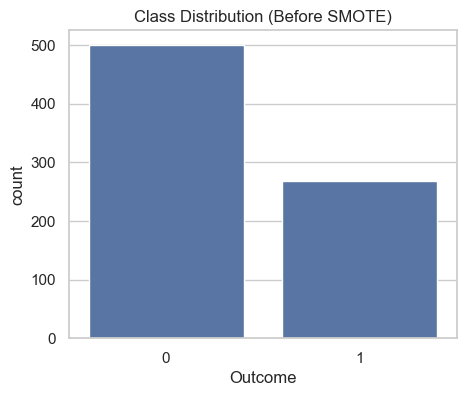

In [4]:
# ============================================
# 4. Check Class Distribution (Outcome)
# ============================================
# Outcome = 0 -> No diabetes
# Outcome = 1 -> Diabetes

class_counts = df["Outcome"].value_counts()
print("Class distribution:\n", class_counts)

plt.figure(figsize=(5,4))
sns.countplot(x="Outcome", data=df)
plt.title("Class Distribution (Before SMOTE)")
plt.show()


In [5]:
# ============================================
# 5. Separate Features (X) and Target (y)
# ============================================
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (768, 8)
Target shape: (768,)


In [6]:
# ============================================
# 6. Apply SMOTE for Class Balancing
# ============================================
# SMOTE creates synthetic samples for the minority class to balance the dataset.

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

print("After SMOTE - class distribution:")
print(pd.Series(y_resampled).value_counts())

# Convert back to DataFrame for easier inspection (optional)
df_smote = pd.DataFrame(X_resampled, columns=X.columns)
df_smote["Outcome"] = y_resampled

df_smote.head()


After SMOTE - class distribution:
Outcome
1    500
0    500
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
# ============================================
# 7. Train/Test Split
# ============================================
# We split the resampled data into training and testing sets.
# stratify=y_resampled ensures the class balance is preserved in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.25,
    random_state=42,
    stratify=y_resampled
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 750
Test set size: 250


In [8]:
# ============================================
# 8. Feature Scaling
# ============================================
# Many models (Logistic Regression, KNN) perform better when features are on a similar scale.
# We use StandardScaler to transform features to mean=0 and std=1.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")


Feature scaling complete.


In [9]:
# ============================================
# 9. Train Multiple Classifiers
# ============================================
# We will train:
# - Logistic Regression
# - Random Forest
# - K-Nearest Neighbors (KNN)
# - Decision Tree

# 9.1 Logistic Regression (uses scaled data)
log_model = LogisticRegression(max_iter=500, random_state=42)
log_model.fit(X_train_scaled, y_train)
print("Logistic Regression training complete.")

# 9.2 Random Forest (tree-based, scaling not required)
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)
print("Random Forest training complete.")

# 9.3 K-Nearest Neighbors (distance-based, scaling important)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
print("KNN training complete.")

# 9.4 Decision Tree (tree-based, scaling not required)
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
dt_model.fit(X_train, y_train)
print("Decision Tree training complete.")


Logistic Regression training complete.
Random Forest training complete.
KNN training complete.
Decision Tree training complete.


In [10]:
# ============================================
# 10. Make Predictions
# ============================================
# Use the appropriate version of X_test (scaled or unscaled) for each model.

log_pred = log_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)
knn_pred = knn_model.predict(X_test_scaled)
dt_pred = dt_model.predict(X_test)

print("Predictions generated for all models.")


Predictions generated for all models.



Logistic Regression - Evaluation
Accuracy: 0.7600


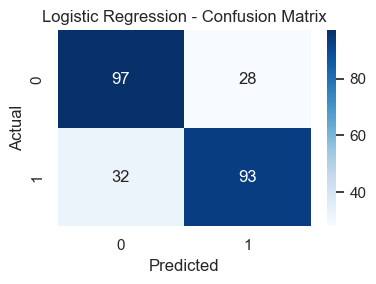

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.78      0.76       125
           1       0.77      0.74      0.76       125

    accuracy                           0.76       250
   macro avg       0.76      0.76      0.76       250
weighted avg       0.76      0.76      0.76       250


Random Forest - Evaluation
Accuracy: 0.8320


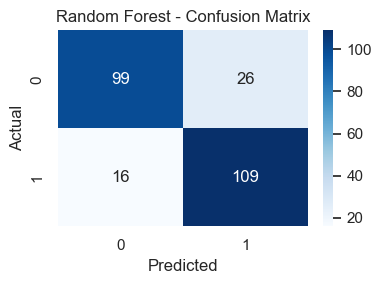

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82       125
           1       0.81      0.87      0.84       125

    accuracy                           0.83       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.83      0.83      0.83       250


KNN - Evaluation
Accuracy: 0.7760


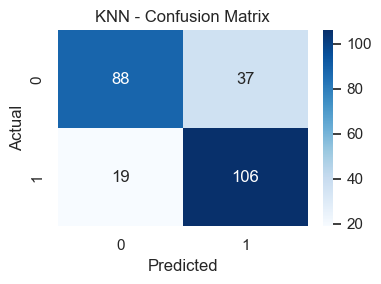

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.70      0.76       125
           1       0.74      0.85      0.79       125

    accuracy                           0.78       250
   macro avg       0.78      0.78      0.77       250
weighted avg       0.78      0.78      0.77       250


Decision Tree - Evaluation
Accuracy: 0.8080


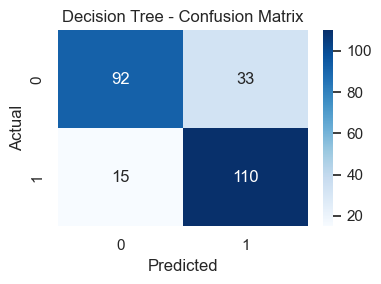

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.74      0.79       125
           1       0.77      0.88      0.82       125

    accuracy                           0.81       250
   macro avg       0.81      0.81      0.81       250
weighted avg       0.81      0.81      0.81       250



In [11]:
# ============================================
# 11. Evaluate All Models
# ============================================
# We will compute:
# - Accuracy
# - Confusion Matrix
# - Precision, Recall, F1-score (Classification Report)

models = {
    "Logistic Regression": log_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred,
    "Decision Tree": dt_pred
}

for name, preds in models.items():
    print("\n" + "="*40)
    print(f"{name} - Evaluation")
    print("="*40)
    
    # Accuracy
    acc = accuracy_score(y_test, preds)
    print(f"Accuracy: {acc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, preds))


In [12]:
# ============================================
# 12. Compare Model Accuracies
# ============================================
accuracy_results = {
    "Logistic Regression": accuracy_score(y_test, log_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "KNN": accuracy_score(y_test, knn_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred)
}

accuracy_df = pd.DataFrame.from_dict(
    accuracy_results, orient="index", columns=["Accuracy"]
).sort_values(by="Accuracy", ascending=False)

print("Model Accuracy Comparison:\n")
accuracy_df


Model Accuracy Comparison:



,Accuracy
Random Forest,0.832
Decision Tree,0.808
KNN,0.776
Logistic Regression,0.760


The ROC curve plots:

True Positive Rate (Recall) on the Y‑axis

False Positive Rate on the X‑axis

It shows how well the model separates the two classes.

A perfect model:
Goes straight up to (0,1)

Then across to (1,1)

A useless model:
Diagonal line (random guessing)

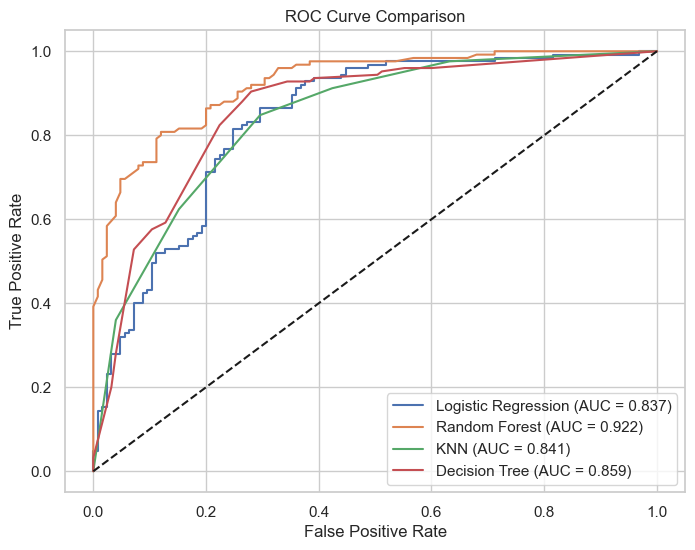

In [13]:
from sklearn.metrics import roc_curve, auc

# Probability predictions (needed for ROC)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
knn_probs = knn_model.predict_proba(X_test_scaled)[:, 1]
dt_probs = dt_model.predict_proba(X_test)[:, 1]

models_probs = {
    "Logistic Regression": log_probs,
    "Random Forest": rf_probs,
    "KNN": knn_probs,
    "Decision Tree": dt_probs
}

plt.figure(figsize=(8,6))

for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')  # Random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()
